# LangGraph MCP - Context7 튜토리얼

이 튜토리얼에서는 **Context7** MCP 서버를 LangGraph와 통합하여 최신 라이브러리 문서를 실시간으로 검색하고 활용하는 방법을 학습합니다.

Context7은 AI 코딩 어시스턴트가 구식 학습 데이터에 의존하는 문제를 해결합니다. 라이브러리의 최신 공식 문서와 코드 예제를 실시간으로 LLM 컨텍스트에 주입하여 **정확하고 최신 코드 생성**을 가능하게 합니다.

> 참고 문서: [Context7 GitHub](https://github.com/upstash/context7) | [Context7 대시보드](https://context7.com/dashboard)

## 학습 목표

- Context7의 개념과 동작 원리를 이해합니다
- Context7 MCP 서버를 설치하고 연결하는 방법을 학습합니다
- `resolve-library-id`와 `query-docs` 도구의 사용법을 익힙니다
- `create_agent`를 사용하여 Context7 기반 AI 에이전트를 구축합니다
- ToolNode를 활용한 커스텀 워크플로우와 Context7을 통합합니다
- 실전 예제를 통해 최신 문서 기반 코드 생성을 경험합니다

## 목차

1. Context7 개요
2. 환경 설정
3. Context7 MCP 연결 기본
4. resolve-library-id 도구 활용
5. query-docs 도구 활용
6. Agent와 Context7 통합
7. ToolNode 기반 커스텀 워크플로우
8. 실전 활용 예제

## 환경 설정

튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 추적을 확인할 수 있도록 합니다.

LangSmith 추적을 활성화하면 에이전트의 추론 과정, 도구 호출, 응답 생성 등을 시각적으로 디버깅할 수 있어 개발에 큰 도움이 됩니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


---

## Part 1: Context7 개요

### Context7이란?

Context7은 AI 코딩 어시스턴트가 **최신, 버전별 공식 문서**를 실시간으로 참조할 수 있도록 지원하는 MCP 서버입니다. LLM은 학습 데이터의 한계로 인해 오래된 API 정보나 존재하지 않는 함수를 생성하는 문제(환각, Hallucination)가 발생합니다. Context7은 이 문제를 근본적으로 해결합니다.

### Context7이 해결하는 문제

| 기존 문제 | Context7 해결책 |
|-----------|----------------|
| 오래된 학습 데이터 기반 코드 생성 | 최신 공식 문서에서 실시간 정보 제공 |
| 존재하지 않는 API 함수 생성 (환각) | 실제 문서 기반 검증된 코드 예제 제공 |
| 구버전 패키지 사용법 안내 | 버전별 정확한 사용법 매칭 |
| 일반적인 답변으로 구체성 부족 | 특정 라이브러리 문서 직접 조회 |

### 주요 특징

- **실시간 문서 검색**: 최신 공식 문서를 즉시 가져와 LLM 컨텍스트에 주입
- **버전 인식**: 특정 버전의 라이브러리 문서를 정확히 매칭
- **스마트 라이브러리 매칭**: 라이브러리 이름을 Context7 ID로 자동 변환
- **npx 즉시 실행**: Node.js 설치만으로 별도 설치 없이 사용 가능
- **MCP 표준 준수**: MCP 프로토콜을 통해 어떤 AI 에이전트와도 연동 가능

### Context7 MCP 도구

Context7은 두 가지 핵심 MCP 도구를 제공합니다:

#### 1. `resolve-library-id`
라이브러리 이름을 Context7 호환 ID로 변환합니다.
- **입력**: `libraryName` (라이브러리 이름), `query` (사용자 질문)
- **출력**: `/org/project` 형태의 Context7 라이브러리 ID
- **용도**: `query-docs` 호출 전 반드시 먼저 실행

#### 2. `query-docs`
라이브러리 ID에 해당하는 최신 문서와 코드 예제를 검색합니다.
- **입력**: `libraryId` (Context7 라이브러리 ID), `query` (검색할 내용)
- **출력**: 해당 라이브러리의 최신 문서 및 코드 예제
- **용도**: 특정 기능의 최신 사용법 조회

### 설치 사전 요구사항

Context7은 `npx`를 통해 실행되므로 **Node.js 18 이상**이 필요합니다.

```bash
# Node.js 버전 확인
node --version  # v18 이상 필요

# npx 동작 확인
npx --version
```

API 키는 선택 사항이지만 더 높은 요청 한도를 위해 권장됩니다:
- 무료 API 키 발급: https://context7.com/dashboard
- `.env` 파일에 `CONTEXT7_API_KEY=your_key` 추가

---

## Part 2: 기본 설정 및 패키지 임포트

Context7 MCP 서버를 사용하기 위해 필요한 패키지들을 임포트합니다. `langchain-mcp-adapters`는 MCP 서버와 LangChain 에이전트를 연결하는 핵심 라이브러리입니다.

```bash
# 필요한 패키지 설치 (아직 설치되지 않은 경우)
uv add langchain-mcp-adapters
```

In [2]:
import nest_asyncio
from typing import List, Dict, Any

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# MCP 클라이언트: 여러 MCP 서버에 연결하여 도구를 가져옵니다
from langchain_mcp_adapters.client import MultiServerMCPClient

# 비동기 호출을 활성화합니다 (Jupyter 환경에서 필요)
nest_asyncio.apply()

---

## Part 3: Context7 MCP 연결 기본

### MCP 클라이언트 설정 헬퍼 함수

`MultiServerMCPClient`를 사용하면 여러 MCP 서버를 동시에 관리하고 각 서버의 도구를 통합하여 사용할 수 있습니다. 아래는 Windows 환경의 Jupyter 호환성 패치와 함께 MCP 클라이언트를 설정하는 헬퍼 함수입니다.

**Windows 호환성 패치**: Windows 환경에서 Jupyter Notebook을 사용할 때 MCP stdio가 Jupyter의 `sys.stderr`를 서브프로세스에 전달하면서 `fileno()` 미지원으로 오류가 발생할 수 있습니다. 이를 방지하기 위한 패치를 포함합니다.

In [3]:
import sys, os

# Windows + Jupyter workaround: MCP stdio passes Jupyter's sys.stderr to subprocess.Popen,
# but Jupyter's stderr doesn't support fileno(). Patch the default errlog to os.devnull.
if sys.platform == "win32":
    import mcp.client.stdio as _mcp_stdio

    _devnull_file = open(os.devnull, "w")

    # @asynccontextmanager wraps the original function — patch __wrapped__.__defaults__
    if hasattr(_mcp_stdio.stdio_client, "__wrapped__"):
        _mcp_stdio.stdio_client.__wrapped__.__defaults__ = (_devnull_file,)

    # Also patch the helper that creates the subprocess
    _mcp_stdio._create_platform_compatible_process.__defaults__ = (
        None,
        _devnull_file,
        None,
    )


async def setup_mcp_client(server_configs: dict):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다.

    Args:
        server_configs: 서버 구성 딕셔너리. 각 서버의 이름을 키로,
                       연결 정보(command, args, transport 또는 url)를 값으로 가집니다.

    Returns:
        tuple: (MCP 클라이언트, 로드된 도구 목록)
    """
    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 도구 목록을 가져옵니다
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력합니다
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}: {tool.description[:80]}..." if len(tool.description) > 80 else f"  - {tool.name}: {tool.description}")

    return client, tools

### Context7 MCP 서버 연결

Context7 MCP 서버는 `npx`를 통해 실행됩니다. `stdio` 전송 방식을 사용하여 클라이언트가 자동으로 서버 프로세스를 관리합니다.

**서버 구성 설명:**
- `command`: `npx` — Node.js 패키지 실행기
- `args`: `["-y", "@upstash/context7-mcp@latest"]` — 자동 승인 후 최신 버전 실행
- `transport`: `stdio` — 표준 입출력을 통한 통신
- `env`: `CONTEXT7_API_KEY` — (선택) 더 높은 요청 한도를 위한 API 키

In [4]:
# Context7 MCP 서버 구성
# CONTEXT7_API_KEY는 선택 사항입니다. .env 파일에 설정하거나 직접 입력하세요.
context7_server_config = {
    "context7": {
        "command": "npx",
        "args": ["-y", "@upstash/context7-mcp@latest"],
        "transport": "stdio",
        # API 키가 있다면 아래 env 설정의 주석을 해제하세요
        # "env": {
        #     "CONTEXT7_API_KEY": os.getenv("CONTEXT7_API_KEY", "")
        # },
    }
}

# MCP 클라이언트 생성 및 도구 로드
client, tools = await setup_mcp_client(server_configs=context7_server_config)

[MCP] 2개의 도구가 로드되었습니다:
  - resolve-library-id: Resolves a package/product name to a Context7-compatible library ID and returns ...
  - query-docs: Retrieves and queries up-to-date documentation and code examples from Context7 f...


### 도구 상세 정보 확인

로드된 Context7 도구의 이름, 설명, 파라미터 스키마를 상세히 확인합니다.

In [5]:
# 로드된 도구 상세 정보 출력
for i, tool in enumerate(tools):
    print(f"\n{'='*60}")
    print(f"도구 {i+1}: {tool.name}")
    print(f"{'='*60}")
    print(f"설명: {tool.description}")
    print(f"\n파라미터 스키마:")
    import json
    if hasattr(tool, 'args_schema') and tool.args_schema:
        schema = tool.args_schema.schema() if hasattr(tool.args_schema, 'schema') else tool.args_schema
        print(json.dumps(schema, indent=2, ensure_ascii=False))


도구 1: resolve-library-id
설명: Resolves a package/product name to a Context7-compatible library ID and returns matching libraries.

You MUST call this function before 'Query Documentation' tool to obtain a valid Context7-compatible library ID UNLESS the user explicitly provides a library ID in the format '/org/project' or '/org/project/version' in their query.

Each result includes:
- Library ID: Context7-compatible identifier (format: /org/project)
- Name: Library or package name
- Description: Short summary
- Code Snippets: Number of available code examples
- Source Reputation: Authority indicator (High, Medium, Low, or Unknown)
- Benchmark Score: Quality indicator (100 is the highest score)
- Versions: List of versions if available. Use one of those versions if the user provides a version in their query. The format of the version is /org/project/version.

For best results, select libraries based on name match, source reputation, snippet coverage, benchmark score, and relevance to you

---

## Part 4: resolve-library-id 도구 활용

### resolve-library-id란?

`resolve-library-id`는 일반적인 라이브러리 이름을 Context7 호환 라이브러리 ID로 변환하는 도구입니다. `query-docs`를 호출하기 전에 반드시 이 도구로 정확한 라이브러리 ID를 먼저 확인해야 합니다.

**반환 형식**: `/org/project` 또는 `/org/project/version`

예시:
- `"LangGraph"` → `/langchain-ai/langgraph`
- `"Next.js"` → `/vercel/next.js`
- `"React"` → `/facebook/react`

아래 코드는 `resolve-library-id` 도구를 직접 호출하여 다양한 라이브러리 ID를 조회합니다.

In [6]:
# resolve-library-id 도구 직접 호출
# tools 리스트에서 resolve-library-id 도구를 찾습니다
resolve_tool = next(t for t in tools if t.name == "resolve-library-id")

# LangGraph 라이브러리 ID 조회
result = await resolve_tool.ainvoke({
    "libraryName": "LangGraph",
    "query": "StateGraph 기반 에이전트 생성"
})
print("LangGraph 라이브러리 ID 조회 결과:")
print(result)

LangGraph 라이브러리 ID 조회 결과:
[{'type': 'text', 'text': 'Available Libraries:\n\n- Title: LangGraph\n- Context7-compatible library ID: /websites/langchain_oss_python_langgraph\n- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.\n- Code Snippets: 670\n- Source Reputation: High\n- Benchmark Score: 86.39\n----------\n- Title: LangGraph\n- Context7-compatible library ID: /langchain-ai/langgraph\n- Description: Build resilient language agents as graphs.\n- Code Snippets: 241\n- Source Reputation: High\n- Benchmark Score: 79.58\n- Versions: 0.2.74, 0.4.8, 0.5.3, 0.6.0, v0_0_8, 0_6_7, 1.0.3, prebuilt__1.0.4, 1.0.6, 1.0.8\n----------\n- Title: LangGraph\n- Context7-compatible library ID: /websites/langchain_oss_javascript_langgraph\n- Description: LangGraph is a low-level orchestration framework and runtime for building,

In [7]:
# 여러 라이브러리 ID를 한 번에 조회합니다
libraries_to_resolve = [
    ("LangChain", "대화형 AI 체인 구성"),
    ("FastAPI", "REST API 엔드포인트 생성"),
    ("Pydantic", "데이터 모델 검증"),
]

print("라이브러리 ID 일괄 조회 결과:")
print("-" * 50)
for lib_name, query in libraries_to_resolve:
    result = await resolve_tool.ainvoke({
        "libraryName": lib_name,
        "query": query
    })
    print(f"\n[{lib_name}]")
    print(result)

라이브러리 ID 일괄 조회 결과:
--------------------------------------------------

[LangChain]
[{'type': 'text', 'text': 'Available Libraries:\n\n- Title: LangChain\n- Context7-compatible library ID: /websites/langchain\n- Description: LangChain is a platform for agent engineering, offering open-source frameworks in Python and TypeScript to build reliable AI agents, alongside LangSmith for continuous testing and improvement.\n- Code Snippets: 20161\n- Source Reputation: High\n- Benchmark Score: 80.35\n----------\n- Title: LangChain\n- Context7-compatible library ID: /websites/langchain_oss\n- Description: LangChain is an open source framework for building agents and LLM-powered applications with pre-built agent architecture, model integrations, and tools for rapid development.\n- Code Snippets: 22031\n- Source Reputation: High\n- Benchmark Score: 74.53\n----------\n- Title: LangChain\n- Context7-compatible library ID: /websites/langchain_oss_python_langchain\n- Description: LangChain is an open-so

---

## Part 5: query-docs 도구 활용

### query-docs란?

`query-docs`는 Context7 라이브러리 ID를 사용하여 해당 라이브러리의 최신 문서와 코드 예제를 검색하는 도구입니다. `resolve-library-id`로 얻은 ID를 입력으로 사용합니다.

**주의사항**: `libraryId`는 반드시 `resolve-library-id`로 얻은 정확한 ID를 사용해야 합니다.

아래 코드는 `query-docs` 도구를 직접 호출하여 LangGraph 문서를 검색합니다.

In [8]:
# query-docs 도구 직접 호출
query_tool = next(t for t in tools if t.name == "query-docs")

# 1단계: 라이브러리 ID 조회
resolve_result = await resolve_tool.ainvoke({
    "libraryName": "LangGraph",
    "query": "StateGraph 노드 및 엣지 추가"
})
print("1단계 - 라이브러리 ID 조회:")
print(resolve_result)
print()

1단계 - 라이브러리 ID 조회:
[{'type': 'text', 'text': 'Available Libraries:\n\n- Title: LangGraph\n- Context7-compatible library ID: /websites/langchain_oss_python_langgraph\n- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.\n- Code Snippets: 670\n- Source Reputation: High\n- Benchmark Score: 86.39\n----------\n- Title: LangGraph\n- Context7-compatible library ID: /langchain-ai/langgraph\n- Description: Build resilient language agents as graphs.\n- Code Snippets: 241\n- Source Reputation: High\n- Benchmark Score: 79.58\n- Versions: 0.2.74, 0.4.8, 0.5.3, 0.6.0, v0_0_8, 0_6_7, 1.0.3, prebuilt__1.0.4, 1.0.6, 1.0.8\n----------\n- Title: LangGraph\n- Context7-compatible library ID: /websites/langchain_oss_javascript_langgraph\n- Description: LangGraph is a low-level orchestration framework and runtime for building, managi

In [9]:
# 2단계: 문서 검색 (resolve-library-id 결과에서 ID를 추출하여 사용)
# 일반적으로 결과에서 '/langchain-ai/langgraphjs' 또는 '/langchain-ai/langgraph' 형태의 ID를 사용합니다
docs_result = await query_tool.ainvoke({
    "libraryId": "/langchain-ai/langgraph",  # resolve-library-id 결과에서 확인한 ID 사용
    "query": "StateGraph 노드 및 엣지 추가 방법"
})
print("2단계 - LangGraph StateGraph 문서 검색 결과:")
print("-" * 60)
# 결과가 길 수 있으므로 처음 2000자만 출력
print(docs_result[:2000] if len(str(docs_result)) > 2000 else docs_result)

2단계 - LangGraph StateGraph 문서 검색 결과:
------------------------------------------------------------
[{'type': 'text', 'text': '### StateGraph - Build Stateful Workflows with Shared State\n\nSource: https://context7.com/langchain-ai/langgraph/llms.txt\n\nStateGraph is the core class for creating node-based workflows where nodes communicate through a shared state object. Each node receives the current state and returns partial updates that are merged using optional reducer functions. The example demonstrates state persistence with checkpointing and thread-based resumable execution.\n\n```python\nfrom typing import Annotated\nfrom typing_extensions import TypedDict\nfrom langgraph.graph import StateGraph, START, END\nfrom langgraph.checkpoint.memory import InMemorySaver\n\n\n# Define state with a reducer for list aggregation\ndef add_to_list(current: list, new: int | None) -> list:\n    if new is not None:\n        return current + [new]\n    return current\n\n\nclass State(TypedDict):\n   

In [10]:
# FastAPI 문서 검색 예제
# 1단계: FastAPI 라이브러리 ID 조회
fastapi_id_result = await resolve_tool.ainvoke({
    "libraryName": "FastAPI",
    "query": "의존성 주입 패턴"
})
print("FastAPI 라이브러리 ID:")
print(fastapi_id_result)
print()

# 2단계: FastAPI 의존성 주입 문서 검색
fastapi_docs = await query_tool.ainvoke({
    "libraryId": "/tiangolo/fastapi",  # resolve 결과에서 확인한 ID
    "query": "의존성 주입(Dependency Injection) 패턴"
})
print("FastAPI 의존성 주입 문서:")
print("-" * 60)
print(fastapi_docs[:2000] if len(str(fastapi_docs)) > 2000 else fastapi_docs)

FastAPI 라이브러리 ID:
[{'type': 'text', 'text': 'Available Libraries:\n\n- Title: FastAPI\n- Context7-compatible library ID: /fastapi/fastapi\n- Description: FastAPI framework, high performance, easy to learn, fast to code, ready for production\n- Code Snippets: 1679\n- Source Reputation: High\n- Benchmark Score: 80.5\n- Versions: 0.115.13, 0_116_1, 0.118.2, 0.122.0, 0.128.0\n----------\n- Title: FastAPI\n- Context7-compatible library ID: /websites/fastapi_tiangolo\n- Description: FastAPI is a modern, high-performance web framework for building APIs with Python, known for its speed, ease of use, and automatic interactive documentation based on OpenAPI standards.\n- Code Snippets: 17409\n- Source Reputation: High\n- Benchmark Score: 84.46\n----------\n- Title: FastAPI\n- Context7-compatible library ID: /websites/fastapi_tiangolo_reference\n- Description: FastAPI is a modern Python web framework for building fast APIs with automatic interactive documentation and built-in validation using Pyt

---

## Part 6: Agent와 Context7 통합

### create_agent 기반 Context7 에이전트

`create_agent`는 LLM과 도구 목록을 전달하면 추론-행동(Reason-Act) 루프를 자동으로 구현하는 에이전트를 생성합니다. Context7 도구를 에이전트에 통합하면, LLM이 필요에 따라 자동으로 `resolve-library-id`와 `query-docs`를 순차적으로 호출합니다.

> 참고: LangGraph v1에서 기존의 `create_react_agent`는 deprecated 되었으며, `langchain.agents.create_agent`를 사용하는 것이 권장됩니다.

아래 코드는 Context7 도구를 사용하는 에이전트를 생성하는 헬퍼 함수를 정의합니다.

In [11]:
async def create_context7_agent():
    """Context7 MCP 도구를 사용하는 에이전트를 생성합니다.

    Returns:
        CompiledStateGraph: 컴파일된 에이전트
    """
    # Context7 MCP 서버 구성
    server_configs = {
        "context7": {
            "command": "npx",
            "args": ["-y", "@upstash/context7-mcp@latest"],
            "transport": "stdio",
        }
    }

    # MCP 클라이언트 생성 및 도구 로드
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # LLM 설정
    # OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
    llm = init_chat_model("claude-sonnet-4-6", temperature=0)

    # 에이전트 생성: Context7 도구를 사용하는 에이전트
    agent = create_agent(
        llm,
        tools,
        checkpointer=InMemorySaver(),  # 대화 상태를 메모리에 저장
    )

    return agent

In [12]:
# Context7 에이전트 생성
agent = await create_context7_agent()

[MCP] 2개의 도구가 로드되었습니다:
  - resolve-library-id: Resolves a package/product name to a Context7-compatible library ID and returns ...
  - query-docs: Retrieves and queries up-to-date documentation and code examples from Context7 f...


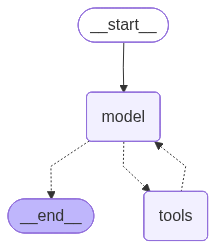

In [13]:
# 에이전트 그래프 구조 확인
agent

### LangGraph 최신 문서 기반 코드 생성

에이전트가 Context7 도구를 사용하여 LangGraph 최신 문서를 조회하고 정확한 코드를 생성하는 과정을 확인합니다. 에이전트는 내부적으로 `resolve-library-id` → `query-docs` 순서로 도구를 자동 호출합니다.

In [14]:
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

# 대화 스레드 ID 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: LangGraph 최신 문서 기반 코드 생성 요청
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "최신 LangGraph 공식 문서를 참조해서 StateGraph로 간단한 챗봇을 만드는 코드를 작성해주세요. context7을 사용해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph 공식 문서를 조회해서 최신 코드를 작성해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- Context7-compatible library ID: /langchain-ai/langgraph
- Description: Build resilient language agents as graphs.
- Code Snippets: 241
- Source Reputation: High
- Benchmark Score: 79.58
- Versions: 0.2.74, 0.4.8, 0.5.3, 0.6.0, v0_0_8, 0_6_7, 1.0.3, prebuilt__1.0.4, 1.0.6, 1.0.8
----------
- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_java

### FastAPI 최신 사용법 조회

FastAPI의 최신 기능과 사용법을 Context7을 통해 조회합니다.

In [15]:
# 새로운 대화 스레드 (독립적인 대화 시작)
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# FastAPI 비동기 처리 최신 문서 조회
response = await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "FastAPI에서 BackgroundTasks를 사용하는 최신 방법을 context7로 검색하고 예제 코드를 보여주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! FastAPI의 BackgroundTasks에 대한 최신 문서를 Context7로 검색해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: FastAPI
- Context7-compatible library ID: /fastapi/fastapi
- Description: FastAPI framework, high performance, easy to learn, fast to code, ready for production
- Code Snippets: 1679
- Source Reputation: High
- Benchmark Score: 80.5
- Versions: 0.115.13, 0_116_1, 0.118.2, 0.122.0, 0.128.0
----------
- Title: FastAPI
- Context7-compatible library ID: /websites/fastapi_tiangolo
- Description: FastAPI is a modern, high-performance web framework for building APIs with Python, known for its speed, ease of use, and automatic interactive documentation based on OpenAPI standards.
- Code Snippets: 17409
- Source Reputation: High
- Benchmark Score: 84.46
----------
- Title: FastAPI
- Context7-compatible library ID: /websites/fastapi_tiangolo_reference
- Description: FastAPI

### 대화 컨텍스트 유지 (다중 턴 대화)

동일한 `thread_id`를 사용하면 이전 대화 내용이 유지됩니다. 같은 주제에 대해 연속으로 질문하면 에이전트가 이전 답변을 참조합니다.

In [16]:
# 같은 thread_id로 연속 대화 (컨텍스트 유지)
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 첫 번째 질문: LangGraph 기본 개념
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "context7을 사용해서 최신 LangGraph에서 interrupt() 함수의 사용법을 찾아주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph의 `interrupt()` 함수 사용법을 찾아보겠습니다. 먼저 라이브러리 ID를 확인하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- Context7-compatible library ID: /langchain-ai/langgraph
- Description: Build resilient language agents as graphs.
- Code Snippets: 241
- Source Reputation: High
- Benchmark Score: 79.58
- Versions: 0.2.74, 0.4.8, 0.5.3, 0.6.0, v0_0_8, 0_6_7, 1.0.3, prebuilt__1.0.4, 1.0.6, 1.0.8
----------
- Title: LangGraph
- Context7-compatible library ID: /web

{'node': 'model',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d332f-cf22-7121-8d68-5d29d92acb07', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4140, 'output_tokens': 1688, 'total_tokens': 5828, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': 'b2892c7c-6b1f-4029-a8df-38d046c0bf71',
  'langgraph_step': 5,
  'langgraph_node': 'model',
  'langgraph_triggers': ('branch:to:model',),
  'langgraph_path': ('__pregel_pull', 'model'),
  'langgraph_checkpoint_ns': 'model:60b0889f-4130-a4ce-1d78-6816dddcb6f4',
  'checkpoint_ns': 'model:60b0889f-4130-a4ce-1d78-6816dddcb6f4',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-6',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1-T

In [17]:
# 두 번째 질문: 이전 대화 컨텍스트를 유지하면서 후속 질문
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "위 내용을 바탕으로 사용자 승인이 필요한 Human-in-the-Loop 패턴 코드를 작성해주세요.",
            )
        ]
    },
    config=config,  # 동일한 thread_id 사용으로 이전 대화 참조
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
바로 최신 LangGraph 문서를 추가로 조회해서 더 정확한 코드를 작성하겠습니다!
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
### Implement a full stateful interrupt workflow in Python

Source: https://docs.langchain.com/oss/python/langgraph/interrupts

A complete example showing how to integrate interrupt-based validation into a LangGraph StateGraph. It includes state definition, node logic, graph compilation with a Sqlite checkpointer, and the usage of Command to resume execution with specific inputs.

```python
import sqlite3
from typing import TypedDict

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

class FormState(TypedDict):
    age: int | None

def get_age_node(state: FormState):
    prompt = "What is your age?"

    while True:
        answer = interrupt(prompt)  # payload surfaces in result["__interrupt__"]

        i

{'node': 'model',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d3330-5583-7ba1-8b6e-8e5bfc38c9f8', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9421, 'output_tokens': 6045, 'total_tokens': 15466, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': 'b2892c7c-6b1f-4029-a8df-38d046c0bf71',
  'langgraph_step': 12,
  'langgraph_node': 'model',
  'langgraph_triggers': ('branch:to:model',),
  'langgraph_path': ('__pregel_pull', 'model'),
  'langgraph_checkpoint_ns': 'model:e642bb85-e8ed-49a4-5968-234f9504f275',
  'checkpoint_ns': 'model:e642bb85-e8ed-49a4-5968-234f9504f275',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-6',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1

---

## Part 7: ToolNode 기반 커스텀 워크플로우

### ToolNode와 Context7

`ToolNode`를 사용하면 LangGraph에서 더 세밀한 제어가 가능한 커스텀 워크플로우를 만들 수 있습니다. `create_agent`와 달리, 그래프의 각 노드를 직접 정의하고 연결하여 복잡한 로직을 구현할 수 있습니다. Context7과 Tavily 검색 도구를 결합하면 **문서 검색 + 웹 검색**을 동시에 활용하는 강력한 에이전트를 만들 수 있습니다.

### 워크플로우 구조

```
START → [agent 노드] → tools_condition → [tools 노드] → [agent 노드] → ...
                                       ↘ END (도구 호출 없을 때)
```

아래 코드는 Context7 + Tavily 검색을 결합한 커스텀 워크플로우를 정의합니다.

In [18]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, TypedDict
from langchain_tavily import TavilySearch


class AgentState(TypedDict):
    """에이전트 상태 정의

    Attributes:
        messages: 대화 메시지 목록. add_messages 리듀서로 메시지가 누적됩니다.
    """
    messages: Annotated[List[BaseMessage], add_messages]


async def create_context7_workflow():
    """Context7 + Tavily 검색을 결합한 커스텀 워크플로우를 생성합니다.

    Context7 도구(문서 검색)와 Tavily 도구(웹 검색)를 함께 사용하여
    공식 문서와 최신 웹 정보를 모두 활용할 수 있는 에이전트를 생성합니다.

    Returns:
        CompiledStateGraph: 컴파일된 워크플로우 그래프
    """
    # Context7 MCP 서버 구성
    server_configs = {
        "context7": {
            "command": "npx",
            "args": ["-y", "@upstash/context7-mcp@latest"],
            "transport": "stdio",
        }
    }

    # MCP 클라이언트 생성 및 Context7 도구 로드
    client, mcp_tools = await setup_mcp_client(server_configs=server_configs)

    # Tavily 웹 검색 도구 추가
    tavily_tool = TavilySearch(max_results=3)
    all_tools = mcp_tools + [tavily_tool]

    print(f"\n총 {len(all_tools)}개 도구 사용:")
    for t in all_tools:
        print(f"  - {t.name}")

    # LLM 설정 및 도구 바인딩
    llm = init_chat_model("claude-sonnet-4-6", temperature=0)
    llm_with_tools = llm.bind_tools(all_tools)

    # 워크플로우 그래프 생성
    workflow = StateGraph(AgentState)

    async def agent_node(state: AgentState):
        """에이전트 노드: LLM을 호출하여 응답을 생성합니다"""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode 생성: 도구 호출을 처리합니다
    tool_node = ToolNode(all_tools)

    # 그래프에 노드 추가
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    # 엣지 정의
    workflow.add_edge(START, "agent")
    # 조건부 엣지: 도구 호출 필요 시 tools로, 아니면 종료
    workflow.add_conditional_edges("agent", tools_condition)
    # 도구 실행 후 다시 에이전트로
    workflow.add_edge("tools", "agent")

    # 그래프 컴파일
    app = workflow.compile(checkpointer=InMemorySaver())

    return app

In [19]:
# 커스텀 워크플로우 생성
workflow_app = await create_context7_workflow()

[MCP] 2개의 도구가 로드되었습니다:
  - resolve-library-id: Resolves a package/product name to a Context7-compatible library ID and returns ...
  - query-docs: Retrieves and queries up-to-date documentation and code examples from Context7 f...

총 3개 도구 사용:
  - resolve-library-id
  - query-docs
  - tavily_search


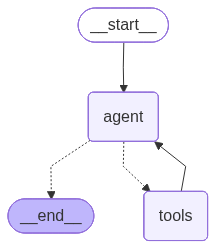

In [20]:
from IPython.display import Image, display

# 워크플로우 그래프 시각화
display(Image(workflow_app.get_graph().draw_mermaid_png()))

### Context7 + Tavily 복합 검색

Context7으로 공식 문서를 검색하고, Tavily로 최신 커뮤니티 정보를 함께 조회합니다.

In [21]:
# 새로운 대화 스레드 설정
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# Context7 + Tavily 복합 검색
# 1. Context7으로 LangGraph 공식 문서 검색
# 2. Tavily로 최신 LangGraph 관련 뉴스/블로그 검색
await astream_graph(
    workflow_app,
    inputs={
        "messages": [
            (
                "human",
                "context7로 LangGraph의 Send API 사용법을 검색하고, Tavily로 LangGraph Send API 관련 최신 정보도 검색해서 종합적으로 설명해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph의 Send API에 대해 Context7과 Tavily를 동시에 활용해서 검색해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_javascript_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents with durable execution, streaming, and human-in-the-loop capabilities.
- Code Snippets: 790
- Source Reputation: High
- Benchmar

{'node': 'agent',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d3332-1446-7c31-b2d4-9cd94651230c', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13378, 'output_tokens': 3612, 'total_tokens': 16990, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': '0f017c6c-f782-47c1-a656-3ad65a49cb3d',
  'langgraph_step': 7,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:abc906aa-e9a8-4ab0-26bc-3f693b199cfd',
  'checkpoint_ns': 'agent:abc906aa-e9a8-4ab0-26bc-3f693b199cfd',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-6',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1

---

## Part 8: 실전 활용 예제

### 예제 1: 다중 라이브러리 비교 분석

여러 라이브러리의 공식 문서를 동시에 참조하여 비교 분석합니다. 에이전트는 각 라이브러리에 대해 순차적으로 `resolve-library-id` → `query-docs`를 호출합니다.

In [22]:
# 새로운 에이전트 생성 (깨끗한 상태에서 시작)
agent = await create_context7_agent()
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 다중 라이브러리 비교: LangGraph vs LangChain LCEL
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "context7을 사용해서 LangGraph와 LangChain LCEL(LangChain Expression Language)의 최신 공식 문서를 각각 검색한 후, "
                "두 방식의 주요 차이점과 각각 어떤 상황에서 사용하면 좋은지 비교 설명해주세요.",
            )
        ]
    },
    config=config,
)

[MCP] 2개의 도구가 로드되었습니다:
  - resolve-library-id: Resolves a package/product name to a Context7-compatible library ID and returns ...
  - query-docs: Retrieves and queries up-to-date documentation and code examples from Context7 f...

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph와 LangChain LCEL 두 가지를 동시에 검색해볼게요. 먼저 각각의 라이브러리 ID를 찾겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- Context7-compatible library ID: /langchain-ai/langgraph
- Description: Build resilient language agents as graphs

CancelledError: 

### 예제 2: 최신 버전 마이그레이션 가이드 생성

특정 라이브러리의 구버전에서 최신 버전으로 마이그레이션하는 방법을 Context7으로 조회합니다.

In [23]:
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# Pydantic v1 → v2 마이그레이션 가이드
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "context7을 사용해서 Pydantic v2의 공식 마이그레이션 문서를 검색하고, "
                "Pydantic v1에서 v2로 업그레이드할 때 주의해야 할 Breaking Changes와 "
                "주요 변경사항을 정리해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! Pydantic v2 마이그레이션 문서를 검색해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: Pydantic
- Context7-compatible library ID: /pydantic/pydantic
- Description: Pydantic is a data validation library for Python that uses type hints to define data schemas, offering fast and extensible validation for applications.
- Code Snippets: 774
- Source Reputation: High
- Benchmark Score: 85.1
----------
- Title: Pydantic
- Context7-compatible library ID: /websites/pydantic_dev
- Description: Pydantic is a fast and extensible data validation library for Python. It uses type hints to define data schemas, enabling powerful validation and serialization.
- Code Snippets: 2547
- Source Reputation: High
- Benchmark Score: 85.51
----------
- Title: Pydantic
- Context7-compatible library ID: /websites/pydantic_dev_2_12
- Description: Pydantic is a fast and extensible data validation librar

{'node': 'model',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d3334-fd21-7180-b15a-1c9f741e3587', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6491, 'output_tokens': 3139, 'total_tokens': 9630, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': '70a96032-a361-404e-bd6d-838176826fbf',
  'langgraph_step': 7,
  'langgraph_node': 'model',
  'langgraph_triggers': ('branch:to:model',),
  'langgraph_path': ('__pregel_pull', 'model'),
  'langgraph_checkpoint_ns': 'model:e3bc70d0-42d4-f6e6-3794-7c6caff103ae',
  'checkpoint_ns': 'model:e3bc70d0-42d4-f6e6-3794-7c6caff103ae',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-6',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1-T

### 예제 3: 실전 프로젝트 코드 생성

Context7으로 최신 문서를 조회하면서 실제 프로젝트에 사용할 수 있는 완성도 높은 코드를 생성합니다.

In [24]:
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 실전 프로젝트: LangGraph + FastAPI 통합 서버 코드 생성
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "context7을 사용해서 최신 LangGraph와 FastAPI 공식 문서를 참조하여, "
                "LangGraph 에이전트를 FastAPI로 서빙하는 REST API 서버 코드를 작성해주세요. "
                "스트리밍 응답도 지원해야 합니다.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph와 FastAPI 공식 문서를 동시에 조회하겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_javascript_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents with durable execution, streaming, and human-in-the-loop capabilities.
- Code Snippets: 790
- Source Reputation: High
- Benchmark Score: 86.06
--------

CancelledError: 

### 예제 4: 특정 버전 문서 조회

Context7은 라이브러리의 특정 버전 문서도 검색할 수 있습니다. `resolve-library-id`에서 버전을 명시하거나 쿼리에 버전 정보를 포함합니다.

In [25]:
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 특정 버전 문서 조회: LangGraph v1 checkpointing
await astream_graph(
    agent,
    inputs={
        "messages": [
            (
                "human",
                "context7을 사용해서 최신 LangGraph 문서에서 PostgreSQL 체크포인터(PostgresSaver) 설정 방법을 검색하고, "
                "실제 사용 가능한 완전한 설정 코드 예제를 제공해주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네! LangGraph의 PostgreSQL 체크포인터 설정 방법을 Context7을 통해 검색해드리겠습니다.
🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Available Libraries:

- Title: LangGraph Redis
- Context7-compatible library ID: /redis-developer/langgraph-redis
- Description: LangGraph Redis provides Redis implementations for LangGraph, offering Checkpoint Savers and Stores with optional vector search capabilities.
- Code Snippets: 548
- Source Reputation: High
- Benchmark Score: 76.43
- Versions: v0.3.2
----------
- Title: LangGraph
- Context7-compatible library ID: /websites/langchain_oss_python_langgraph
- Description: LangGraph is a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents, offering durable execution, human-in-the-loop capabilities, and comprehensive memory.
- Code Snippets: 670
- Source Reputation: High
- Benchmark Score: 86.39
----------
- Title: LangGraph
- C

{'node': 'model',
 'content': AIMessageChunk(content=[], additional_kwargs={}, response_metadata={'stop_reason': 'end_turn', 'stop_sequence': None, 'model_provider': 'anthropic'}, id='lc_run--019d3337-a7d7-7d21-9643-21441f79febf', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6691, 'output_tokens': 3299, 'total_tokens': 9990, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}, tool_call_chunks=[], chunk_position='last'),
 'metadata': {'thread_id': '29b0eaee-f217-40d8-b1c0-10f0a074a5c9',
  'langgraph_step': 7,
  'langgraph_node': 'model',
  'langgraph_triggers': ('branch:to:model',),
  'langgraph_path': ('__pregel_pull', 'model'),
  'langgraph_checkpoint_ns': 'model:26747eae-b397-0c40-0edd-ab1701b91aad',
  'checkpoint_ns': 'model:26747eae-b397-0c40-0edd-ab1701b91aad',
  'ls_provider': 'anthropic',
  'ls_model_name': 'claude-sonnet-4-6',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_max_tokens': 64000,
  'LANGSMITH_PROJECT': 'LangGraph-V1-T

---

## 요약

이 튜토리얼에서는 Context7 MCP 서버를 LangGraph와 통합하는 전체 과정을 학습했습니다.

### 핵심 정리

| 개념 | 내용 |
|------|------|
| **Context7** | 최신 라이브러리 공식 문서를 실시간으로 LLM 컨텍스트에 주입하는 MCP 서버 |
| **resolve-library-id** | 라이브러리 이름 → Context7 호환 ID 변환 도구 |
| **query-docs** | Context7 ID로 최신 문서 및 코드 예제 검색 도구 |
| **MCP 연결** | `npx -y @upstash/context7-mcp@latest` + stdio 전송 방식 |
| **에이전트 통합** | `create_agent`로 자동 도구 호출 루프 구현 |
| **커스텀 워크플로우** | `ToolNode` + `StateGraph`로 세밀한 흐름 제어 |

### Context7 활용 팁

1. **항상 `resolve-library-id` 먼저 호출**: 정확한 라이브러리 ID 없이 `query-docs`를 호출하면 오류 발생
2. **구체적인 쿼리 작성**: "사용법" 보다는 "백그라운드 작업 처리 예제 코드"처럼 구체적일수록 정확한 문서 반환
3. **API 키 설정 권장**: 무료 API 키로도 더 높은 요청 한도 확보 가능
4. **Tavily와 조합**: Context7(공식 문서) + Tavily(웹 검색) 조합으로 가장 포괄적인 정보 획득
5. **"use context7" 프롬프트**: 에이전트에게 Context7 사용을 명시적으로 지시하면 더 일관된 결과

### 다음 단계

- `06-MCP/` 폴더의 다른 MCP 튜토리얼을 통해 다양한 MCP 서버 활용법 학습
- [Smithery AI](https://smithery.ai/)에서 다양한 3rd Party MCP 서버 탐색
- Context7 + LangGraph + 사용자 정의 도구를 결합한 프로덕션 에이전트 구축